In [ ]:
# Phase 1: Setup and Data Loading

# install libraries
!pip install pandas numpy scikit-learn matplotlib seaborn

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# mount drive
from google.colab import drive
drive.mount('/content/drive')

# file path (change if your file is inside a folder)
file_path = '/content/drive/MyDrive/cyberbullying_tweets.csv'

# load dataset
df = pd.read_csv(file_path)

# basic checks
print("Dataset shape:", df.shape)

# view data
df.head()

Mounted at /content/drive
Dataset shape: (47692, 2)


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [ ]:
# check columns
print("Columns:", df.columns)

# check missing values
print(df.isnull().sum())

# check class distribution
print(df['cyberbullying_type'].value_counts())

Columns: Index(['tweet_text', 'cyberbullying_type'], dtype='object')
tweet_text            0
cyberbullying_type    0
dtype: int64
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


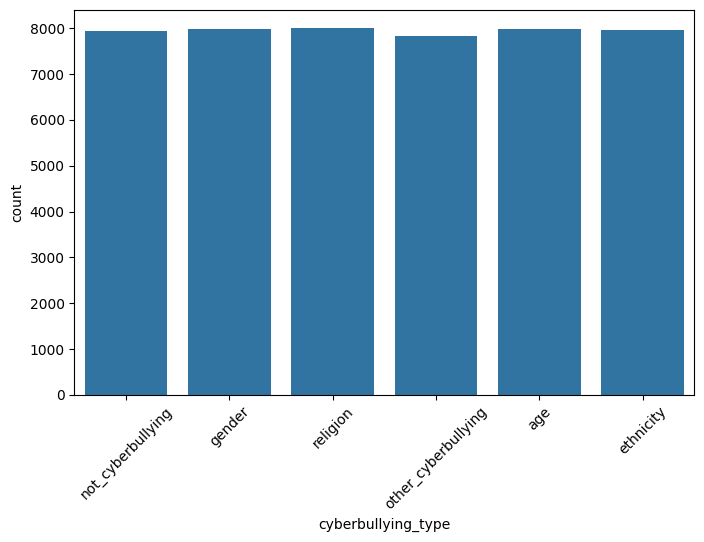

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='cyberbullying_type', data=df)
plt.xticks(rotation=45)
plt.show()

Data Preprocessing

In [ ]:
# Phase 2: Data Cleaning and Preprocessing

import re
from sklearn.preprocessing import LabelEncoder

# make a copy of original data
data = df.copy()

# convert text to lowercase
data['tweet_text'] = data['tweet_text'].astype(str).str.lower()

# function to clean text
def clean_text(text):
    text = re.sub(r"http\S+", " ", text)          # remove links
    text = re.sub(r"@\w+", " ", text)             # remove mentions
    text = re.sub(r"#\w+", " ", text)             # remove hashtags
    text = re.sub(r"[^a-z\s]", " ", text)         # keep only letters
    text = re.sub(r"\s+", " ", text).strip()      # remove extra spaces
    return text

# apply cleaning
data['clean_text'] = data['tweet_text'].apply(clean_text)

# remove empty rows after cleaning
data = data[data['clean_text'].str.strip() != ""]

# reset index
data = data.reset_index(drop=True)

# encode labels
encoder = LabelEncoder()
data['label'] = encoder.fit_transform(data['cyberbullying_type'])

# check mapping
label_map = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label mapping:")
print(label_map)

# check processed data
data[['clean_text', 'label']].head()

Label mapping:
{'age': np.int64(0), 'ethnicity': np.int64(1), 'gender': np.int64(2), 'not_cyberbullying': np.int64(3), 'other_cyberbullying': np.int64(4), 'religion': np.int64(5)}


,clean_text,label
0,in other words your food was crapilicious,3
1,why is so white,3
2,a classy whore or more red velvet cupcakes,3
3,meh p thanks for the heads up but not too conc...,3
4,this is an isis account pretending to be a kur...,3


In [ ]:
# check data size after cleaning
print("New shape:", data.shape)

# check class balance again
print(data['label'].value_counts())

New shape: (47303, 4)
label
5    7998
0    7992
1    7955
2    7935
3    7815
4    7608
Name: count, dtype: int64


train-test split and baseline model

In [ ]:
# Phase 3: Train-Test Split and Baseline Model

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# define input and output
X = data['clean_text']
y = data['label']

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# convert text into numeric features
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# train baseline model
baseline_model = LogisticRegression(max_iter=200)
baseline_model.fit(X_train_vec, y_train)

print("Baseline model training completed")

Training size: (37842,)
Testing size: (9461,)
Baseline model training completed


In [ ]:
# quick prediction check
sample_preds = baseline_model.predict(X_test_vec[:5])
print("Sample predictions:", sample_preds)

Sample predictions: [4 5 5 5 5]


evaluation of baseline model

In [ ]:
# Phase 4: Evaluation of Baseline Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# predictions on test data
y_pred = baseline_model.predict(X_test_vec)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.8191523094810274

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1598
           1       0.97      0.97      0.97      1591
           2       0.89      0.82      0.85      1587
           3       0.57      0.54      0.55      1563
           4       0.58      0.65      0.61      1522
           5       0.94      0.95      0.94      1600

    accuracy                           0.82      9461
   macro avg       0.82      0.82      0.82      9461
weighted avg       0.82      0.82      0.82      9461


Confusion Matrix:

[[1566    1    1   20    9    1]
 [   2 1545    7   12   22    3]
 [   4    7 1295  149  126    6]
 [  46   16   70  847  529   55]
 [  17   19   72  405  984   25]
 [   0    1    7   58   21 1513]]


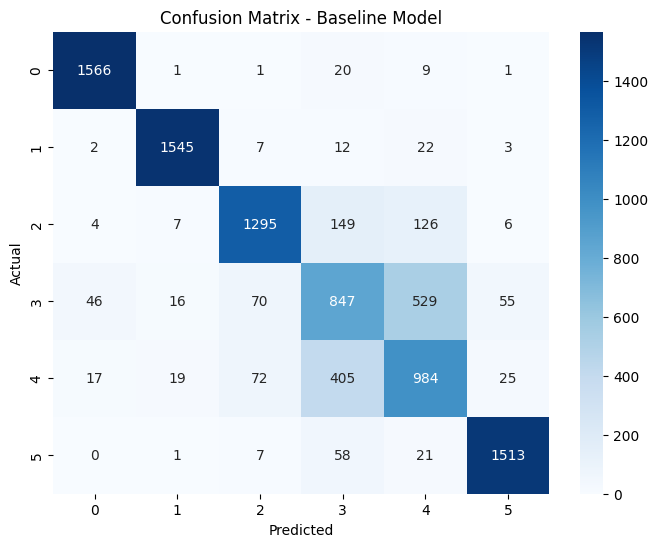

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")
plt.show()

Transformer Model Setup (BERT)

In [ ]:
# Phase 5: Transformer Model Setup

!pip install transformers datasets torch

import torch
from datasets import Dataset
from transformers import BertTokenizer, BertForSequenceClassification

# prepare data for transformer
train_texts = list(X_train)
test_texts = list(X_test)

train_labels = list(y_train)
test_labels = list(y_test)

# create dataset objects
train_dataset = Dataset.from_dict({
    'text': train_texts,
    'label': train_labels
})

test_dataset = Dataset.from_dict({
    'text': test_texts,
    'label': test_labels
})

# load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# tokenize function
def tokenize_function(example):
    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# apply tokenization
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# set format for pytorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# load model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(set(y))
)

print("Transformer model setup completed")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/37842 [00:00<?, ? examples/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transformer model setup completed


In [ ]:
# Phase 6: Training the BERT Model

from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

print("BERT model training completed")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,0.673672
1000,0.497095
1500,0.451156
2000,0.414832
2500,0.418449
3000,0.419661
3500,0.403111
4000,0.394860
4500,0.362812


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model training completed


In [ ]:
# Phase 7: Evaluate BERT Model

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# get predictions from BERT
predictions = trainer.predict(test_dataset)

# convert logits to predicted labels
y_pred_bert = np.argmax(predictions.predictions, axis=1)

# accuracy
bert_acc = accuracy_score(y_test, y_pred_bert)
print("BERT Accuracy:", bert_acc)

# classification report
print("\nBERT Classification Report:\n")
print(classification_report(y_test, y_pred_bert))

# confusion matrix
cm_bert = confusion_matrix(y_test, y_pred_bert)
print("\nBERT Confusion Matrix:\n")
print(cm_bert)

BERT Accuracy: 0.8506500369939752

BERT Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1598
           1       0.99      0.97      0.98      1591
           2       0.89      0.87      0.88      1587
           3       0.65      0.58      0.61      1563
           4       0.64      0.72      0.68      1522
           5       0.95      0.97      0.96      1600

    accuracy                           0.85      9461
   macro avg       0.85      0.85      0.85      9461
weighted avg       0.85      0.85      0.85      9461


BERT Confusion Matrix:

[[1561    4    0   24    9    0]
 [   1 1546    5   12   20    7]
 [   0    3 1375  109   95    5]
 [   9    5   82  910  494   63]
 [   5    8   84  323 1099    3]
 [   0    3    2   25   13 1557]]


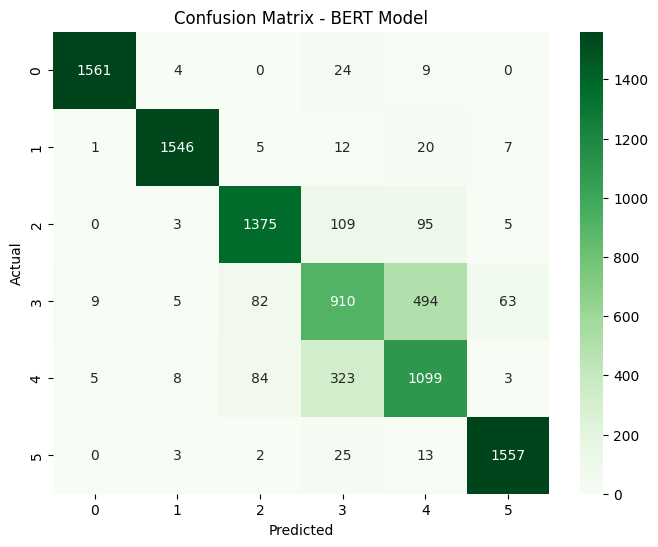

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BERT Model")
plt.show()

In [ ]:
print("Model Comparison")

print("Baseline Accuracy:", acc)
print("BERT Accuracy:", bert_acc)

Model Comparison
Baseline Accuracy: 0.8191523094810274
BERT Accuracy: 0.8506500369939752


In [ ]:
# Phase 8: Error Analysis

# find wrong predictions
errors = []

for i in range(len(y_test)):
    if y_test.iloc[i] != y_pred_bert[i]:
        errors.append((X_test.iloc[i], y_test.iloc[i], y_pred_bert[i]))

# convert to dataframe
error_df = pd.DataFrame(errors, columns=['text', 'actual', 'predicted'])

print("Total errors:", len(error_df))

# show few examples
error_df.head(10)

Total errors: 1413


,text,actual,predicted
0,you could say the new victoriastan lockdown ga...,5,4
1,it s obvious that this guy is one of putin s p...,3,4
2,ahaha there is a piece of cake they made out o...,4,3
3,thank you d,4,3
4,i i thought you were being snarky,3,4
5,so she can try amp claim innocence but statist...,3,4
6,feminazi r anti men because it says femi every...,4,2
7,remember when,3,4
8,haha mt this makes me laugh every single time,4,3
9,him seh me pussy wetter then a shower curtain ...,4,2


In [ ]:
# check most common mistakes
print(error_df['actual'].value_counts())

actual
3    653
4    423
2    212
1     45
5     43
0     37
Name: count, dtype: int64


In [ ]:
# Phase 9: Prediction System

import torch

# function to predict class from new text
def predict_text(text):

    # clean text (same as training)
    text = text.lower()
    import re
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # move to same device as model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # prediction
    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    # convert label number back to original class
    label_name = encoder.inverse_transform([pred])[0]

    return label_name

In [ ]:
print(predict_text("You are such a stupid person"))
print(predict_text("I respect your opinion"))
print(predict_text("People like you should not exist"))

other_cyberbullying
other_cyberbullying
other_cyberbullying
